# OCR Service Evaluation Notebook

Notebook này benchmark OCR service:
- Gọi API `/ocr/prescriptions/parse`
- So sánh với ground truth
- Tính metrics
- Vẽ charts

## Dataset format

Ví dụ:
- `dataset/images/abc.jpg`
- `dataset/labels/abc.json`

Label JSON mẫu:

```json
{
  "items": [
    {
      "name": "Paracetamol",
      "strength": "500mg",
      "dose_amount": "1 viên",
      "dosage": "1 viên",
      "times_per_day": 2,
      "specific_times": ["08:00", "20:00"],
      "instructions": "Uống sau ăn"
    }
  ]
}
```

In [1]:
# If needed: pip install requests pandas rapidfuzz matplotlib seaborn
import json
import re
from pathlib import Path
from typing import Any

import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from rapidfuzz import fuzz

In [2]:
# ===== Config =====
# Local quick-eval mặc định gọi trực tiếp OCR service (không qua gateway).
BASE_URL = "http://localhost:8010"
OCR_ENDPOINT = f"{BASE_URL}/ocr/prescriptions/parse"
ACCESS_TOKEN = ""  # nếu gọi qua gateway có JWT thì dán token và đổi BASE_URL=8080

DATASET_DIR = Path("dataset")
IMAGE_DIR = DATASET_DIR / "images"
LABEL_DIR = DATASET_DIR / "labels"

assert IMAGE_DIR.exists(), f"Missing image dir: {IMAGE_DIR}"
assert LABEL_DIR.exists(), f"Missing label dir: {LABEL_DIR}"

headers = {"Authorization": f"Bearer {ACCESS_TOKEN}"} if ACCESS_TOKEN else {}

In [3]:
def norm_text(s: str) -> str:
    s = (s or "").lower().strip()
    s = re.sub(r"\([^)]*\)", " ", s)
    s = re.sub(r"[^a-z0-9à-ỹ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def score_name(pred: str, gt: str) -> float:
    return fuzz.ratio(norm_text(pred), norm_text(gt)) / 100.0


def score_field(pred: str, gt: str) -> float:
    if not pred and not gt:
        return 1.0
    return fuzz.ratio((pred or "").strip().lower(), (gt or "").strip().lower()) / 100.0


def times_to_str(item: dict[str, Any]) -> str:
    vals = item.get("specific_times") or []
    if isinstance(vals, list):
        return ",".join(str(v) for v in vals)
    return str(vals or "")


def call_ocr(image_path: Path) -> dict[str, Any]:
    with image_path.open("rb") as f:
        files = {"file": (image_path.name, f, "application/octet-stream")}
        r = requests.post(OCR_ENDPOINT, headers=headers, files=files, timeout=180)
    r.raise_for_status()
    return r.json()

In [4]:
rows = []
all_images = sorted([p for p in IMAGE_DIR.iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'}])

for img_path in all_images:
    label_path = LABEL_DIR / f"{img_path.stem}.json"
    if not label_path.exists():
        rows.append({"image": img_path.name, "status": "missing_label"})
        continue

    gt = json.loads(label_path.read_text(encoding="utf-8"))
    gt_items = gt.get("items", [])

    try:
        pred = call_ocr(img_path)
        pred_items = pred.get("items", [])
        warnings = pred.get("warnings", [])

        # Simple greedy matching by name similarity
        used = set()
        name_scores, strength_scores, dose_amount_scores, time_scores, inst_scores = [], [], [], [], []

        def get_strength(x):
            return str(x.get("strength", x.get("dosage", "")))

        def get_dose_amount(x):
            return str(x.get("dose_amount", x.get("dosage", "")))

        for g in gt_items:
            best_i, best_s = None, -1.0
            for i, p in enumerate(pred_items):
                if i in used:
                    continue
                s = score_name(str(p.get("name", "")), str(g.get("name", "")))
                if s > best_s:
                    best_s, best_i = s, i

            if best_i is not None:
                used.add(best_i)
                p = pred_items[best_i]
                name_scores.append(best_s)
                strength_scores.append(score_field(get_strength(p), get_strength(g)))
                dose_amount_scores.append(score_field(get_dose_amount(p), get_dose_amount(g)))
                time_scores.append(score_field(times_to_str(p), times_to_str(g)))
                inst_scores.append(score_field(str(p.get("instructions", "")), str(g.get("instructions", ""))))
            else:
                name_scores.append(0.0)
                strength_scores.append(0.0)
                dose_amount_scores.append(0.0)
                time_scores.append(0.0)
                inst_scores.append(0.0)

        tp_like = len(used)
        fp = max(0, len(pred_items) - tp_like)
        fn = max(0, len(gt_items) - tp_like)

        rows.append({
            "image": img_path.name,
            "status": "ok",
            "gt_count": len(gt_items),
            "pred_count": len(pred_items),
            "tp_like": tp_like,
            "fp": fp,
            "fn": fn,
            "name_acc": sum(name_scores) / max(1, len(name_scores)),
            "strength_acc": sum(strength_scores) / max(1, len(strength_scores)),
            "dose_amount_acc": sum(dose_amount_scores) / max(1, len(dose_amount_scores)),
            "time_acc": sum(time_scores) / max(1, len(time_scores)),
            "inst_acc": sum(inst_scores) / max(1, len(inst_scores)),
            "warnings_count": len(warnings),
            "ocr_score": pred.get("meta", {}).get("ocr_score", None),
            "pass_used": pred.get("meta", {}).get("pass_used", ""),
        })
    except Exception as e:
        rows.append({"image": img_path.name, "status": "error", "error": str(e)})

df = pd.DataFrame(rows)
df.head()

,image,status,gt_count,pred_count,tp_like,fp,fn,name_acc,strength_acc,dose_amount_acc,time_acc,inst_acc,warnings_count,ocr_score,pass_used
0,041fec48-0760-48d5-a8fb-73b72843c8c7.jpg,ok,3,3,3,0,0,0.255773,0.0,0.641026,0.75,0.956386,3,1.0,adaptive
1,0760c8f6-adbd-4254-9418-a62ba6d6916d.jpg,ok,2,2,2,0,0,1.000000,0.0,0.500000,1.00,1.000000,2,1.0,adaptive
2,2fcc5be2-d1f8-47eb-929b-aa36e46a8261.jpg,ok,2,2,2,0,0,1.000000,0.0,0.500000,1.00,1.000000,2,1.0,enhanced_no_crop_retry
3,34f388e2-6d7b-4f0d-8de8-23ac3de37c51.jpg,ok,2,2,2,0,0,0.750000,0.0,0.500000,1.00,1.000000,2,1.0,enhanced_no_crop_retry
4,544a2e2e-9f19-4d68-9f6f-cb018dd83c91.jpg,ok,4,4,4,0,0,0.242577,0.0,0.500000,0.85,0.978155,4,1.0,adaptive


Total images: 47
OK: 47
Errors: 0
{
  "name_acc_mean": 0.5539220237429242,
  "strength_acc_mean": 0.1442334000008772,
  "dose_amount_acc_mean": 0.4720655189120236,
  "time_acc_mean": 0.7400814374750545,
  "inst_acc_mean": 0.7014724940231436,
  "fp_mean": 0.2553191489361702,
  "fn_mean": 0.8723404255319149,
  "warnings_mean": 3.74468085106383
}


C:\Users\aiiuu\AppData\Local\Temp\ipykernel_23520\4279351402.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=metric_df, x="metric", y="score", palette="Greens_d")


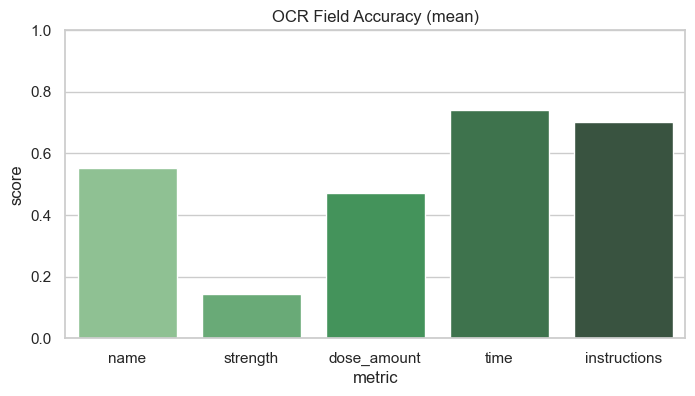

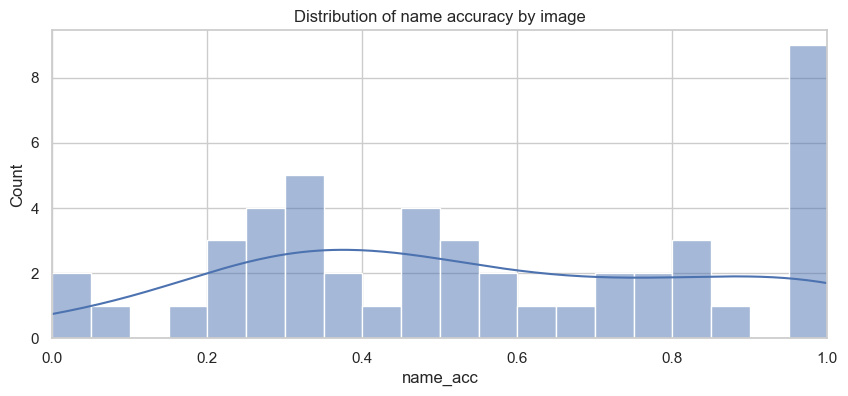

Saved: reports\ocr_eval_per_image.csv
Saved: reports\ocr_eval_summary.json


In [5]:
ok = df[df["status"] == "ok"].copy()
print("Total images:", len(df))
print("OK:", len(ok))
print("Errors:", (df["status"] == "error").sum())

if len(ok) > 0:
    summary = {
        "name_acc_mean": ok["name_acc"].mean(),
        "strength_acc_mean": ok["strength_acc"].mean(),
        "dose_amount_acc_mean": ok["dose_amount_acc"].mean(),
        "time_acc_mean": ok["time_acc"].mean(),
        "inst_acc_mean": ok["inst_acc"].mean(),
        "fp_mean": ok["fp"].mean(),
        "fn_mean": ok["fn"].mean(),
        "warnings_mean": ok["warnings_count"].mean(),
    }
    print(json.dumps(summary, indent=2, ensure_ascii=False))

    metric_df = pd.DataFrame([
        {"metric": "name", "score": summary["name_acc_mean"]},
        {"metric": "strength", "score": summary["strength_acc_mean"]},
        {"metric": "dose_amount", "score": summary["dose_amount_acc_mean"]},
        {"metric": "time", "score": summary["time_acc_mean"]},
        {"metric": "instructions", "score": summary["inst_acc_mean"]},
    ])

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=metric_df, x="metric", y="score", palette="Greens_d")
    ax.set_ylim(0, 1)
    ax.set_title("OCR Field Accuracy (mean)")
    plt.show()

    plt.figure(figsize=(10, 4))
    sns.histplot(ok["name_acc"], bins=20, kde=True)
    plt.title("Distribution of name accuracy by image")
    plt.xlim(0, 1)
    plt.show()

    # Save report
    out_dir = Path("reports")
    out_dir.mkdir(exist_ok=True)
    ok.to_csv(out_dir / "ocr_eval_per_image.csv", index=False, encoding="utf-8-sig")
    Path(out_dir / "ocr_eval_summary.json").write_text(
        json.dumps(summary, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    print("Saved:", out_dir / "ocr_eval_per_image.csv")
    print("Saved:", out_dir / "ocr_eval_summary.json")